In [41]:
from modulos.data_load import load
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [43]:
10 // 3

3

In [47]:
df = load('AAVEBTC')
df

,unix,date,symbol,open,high,low,close,Volume AAVE,Volume BTC,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage
41405,1602288000000,2020-10-10 00:00:00,AAVE/BTC,0.003800,0.009801,0.003800,0.004801,0.001804,0.338493,0.0,0.0,0,0.005331
41404,1602352800000,2020-10-10 18:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000380,0.100026,0.0,0.0,0,0.000000
41403,1602356400000,2020-10-10 19:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000
41402,1602360000000,2020-10-10 20:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000
41401,1602363600000,2020-10-10 21:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398
3,1751403600000,2025-07-01 21:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398
2,1751407200000,2025-07-01 22:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398
1,1751410800000,2025-07-01 23:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398


In [26]:
predictors = [ 'unix', 'Volume AAVE', 'Volume BTC', 'tradeCount', 'weightedAverage' ]
outcome = 'close'

X = df[predictors]
y = df[outcome]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.73337544, -0.42295094, -0.4478413 , -0.48562777,  2.69946448],
       [-1.73186963, -0.42758056, -0.45041118, -0.48562777, -1.13293601],
       [-1.73178597, -0.42881603, -0.45148912, -0.48562777, -1.13293601],
       ...,
       [ 1.73183488, -0.42881603, -0.45148912, -0.48562777,  0.59101947],
       [ 1.73191853, -0.42881603, -0.45148912, -0.48562777,  0.59101947],
       [ 1.73200219, -0.42881603, -0.45148912, -0.48562777,  0.59101947]],
      shape=(41406, 5))

In [27]:
regg = MLPRegressor(hidden_layer_sizes=(50,100,50), activation='relu', max_iter=800, random_state=1)
regg.fit(X_scaled, y)
regg.predict(X_scaled)

array([0.00307202, 0.00311094, 0.00315735, ..., 0.00128096, 0.0012798 ,
       0.00127864], shape=(41406,))

In [28]:
len(set(regg.predict(X_scaled)))

41406

In [29]:
dff = df
dff['PREDICTED'] = regg.predict(X_scaled)
dff

,unix,date,symbol,open,high,low,close,Volume AAVE,Volume BTC,buyTakerAmount,buyTakerQuantity,tradeCount,weightedAverage,PREDICTED
41405,1602288000000,2020-10-10 00:00:00,AAVE/BTC,0.003800,0.009801,0.003800,0.004801,0.001804,0.338493,0.0,0.0,0,0.005331,0.003072
41404,1602352800000,2020-10-10 18:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000380,0.100026,0.0,0.0,0,0.000000,0.003111
41403,1602356400000,2020-10-10 19:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000,0.003157
41402,1602360000000,2020-10-10 20:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000,0.003158
41401,1602363600000,2020-10-10 21:00:00,AAVE/BTC,0.003800,0.003800,0.003800,0.003800,0.000000,0.000000,0.0,0.0,0,0.000000,0.003158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1751400000000,2025-07-01 20:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001283
3,1751403600000,2025-07-01 21:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001282
2,1751407200000,2025-07-01 22:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001281
1,1751410800000,2025-07-01 23:00:00,AAVE/BTC,0.002398,0.002398,0.002398,0.002398,0.000000,0.000000,0.0,0.0,0,0.002398,0.001280


In [30]:
dff = dff[[ 'symbol', 'date', 'close', 'PREDICTED' ]].rename(columns={ 'close': 'FECHAMENTO REAL' })
dff['ERRO'] = dff[['FECHAMENTO REAL', 'PREDICTED']].apply(lambda row: abs(row['FECHAMENTO REAL'] - row['PREDICTED']), axis=1)
dff

,symbol,date,FECHAMENTO REAL,PREDICTED,ERRO
41405,AAVE/BTC,2020-10-10 00:00:00,0.004801,0.003072,0.001729
41404,AAVE/BTC,2020-10-10 18:00:00,0.003800,0.003111,0.000689
41403,AAVE/BTC,2020-10-10 19:00:00,0.003800,0.003157,0.000643
41402,AAVE/BTC,2020-10-10 20:00:00,0.003800,0.003158,0.000642
41401,AAVE/BTC,2020-10-10 21:00:00,0.003800,0.003158,0.000642
...,...,...,...,...,...
4,AAVE/BTC,2025-07-01 20:00:00,0.002398,0.001283,0.001115
3,AAVE/BTC,2025-07-01 21:00:00,0.002398,0.001282,0.001116
2,AAVE/BTC,2025-07-01 22:00:00,0.002398,0.001281,0.001117
1,AAVE/BTC,2025-07-01 23:00:00,0.002398,0.001280,0.001118


In [31]:
dff[dff['ERRO'] == dff['ERRO'].max()]

,symbol,date,FECHAMENTO REAL,PREDICTED,ERRO
34939,AAVE/BTC,2021-07-07 03:00:00,0.009486,0.075255,0.065768


In [32]:
dff[dff['ERRO'] == dff['ERRO'].min()]

,symbol,date,FECHAMENTO REAL,PREDICTED,ERRO
5220,AAVE/BTC,2024-11-26 12:00:00,0.001835,0.001835,1.872238e-09


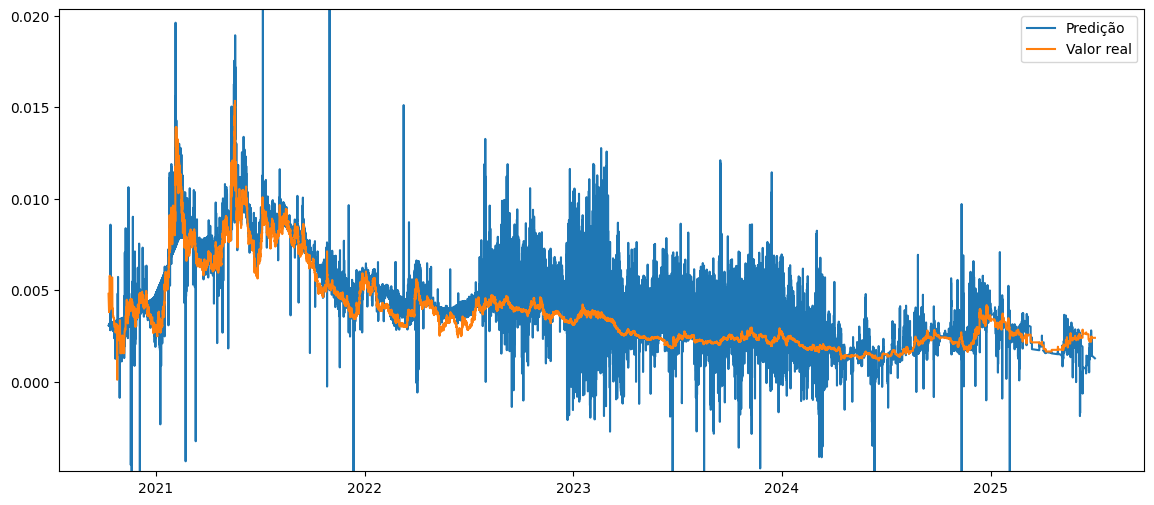

In [40]:
plt.figure(figsize=(14, 6))
plt.plot(dff['date'], dff['PREDICTED'], label='Predição')
plt.plot(dff['date'], dff['FECHAMENTO REAL'], label='Valor real')
plt.ylim(dff['FECHAMENTO REAL'].min()-0.005, dff['FECHAMENTO REAL'].max()+0.005)
plt.legend()